In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

with open("../students_weights/encoder_train/distillation_summary.json", "r") as f:
    data = json.load(f)

resnet_students = pd.DataFrame([d for d in data if d["teacher"] == "resnet"])
convnext_students = pd.DataFrame([d for d in data if d["teacher"] == "convnext"])
vgg_students = pd.DataFrame([d for d in data if d["teacher"] == "vgg"])
vgg_students


FileNotFoundError: [Errno 2] No such file or directory: '../students_weights/encoder_train/distillation_summary.json'

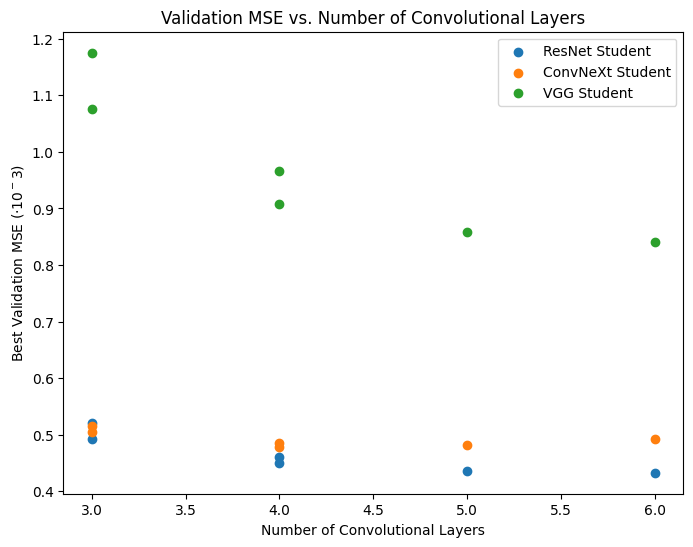

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(resnet_students["n_convs"], resnet_students["best_val_mse"]*1e3, label="ResNet Student", marker="o")
plt.scatter(convnext_students["n_convs"], convnext_students["best_val_mse"]*1e3, label="ConvNeXt Student", marker="o")
plt.scatter(vgg_students["n_convs"], vgg_students["best_val_mse"]*1e3, label="VGG Student", marker="o")
plt.xlabel("Number of Convolutional Layers")
plt.ylabel("Best Validation MSE ($ \\cdot 10^-3$)")
plt.title("Validation MSE vs. Number of Convolutional Layers")
plt.legend()
plt.show()

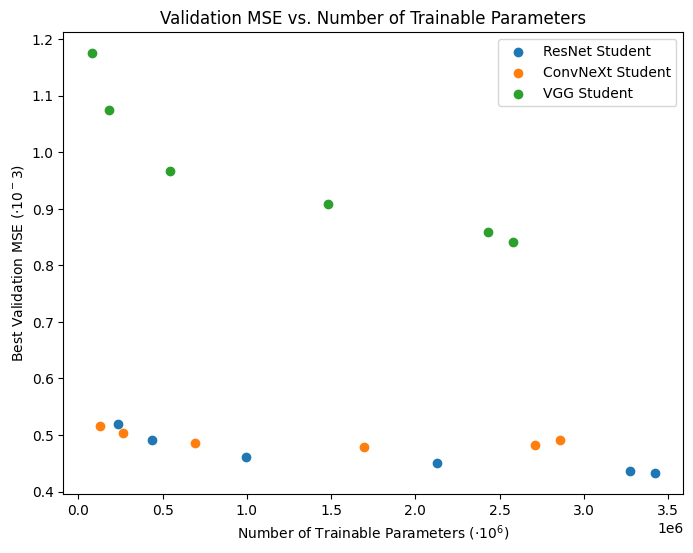

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(resnet_students["trainable_params"], resnet_students["best_val_mse"]*1e3, label="ResNet Student", marker="o")
plt.scatter(convnext_students["trainable_params"], convnext_students["best_val_mse"]*1e3, label="ConvNeXt Student", marker="o")
plt.scatter(vgg_students["trainable_params"], vgg_students["best_val_mse"]*1e3, label="VGG Student", marker="o")
plt.xlabel("Number of Trainable Parameters ($\\cdot10^6$)")
plt.ylabel("Best Validation MSE ($ \\cdot 10^-3$)")
plt.title("Validation MSE vs. Number of Trainable Parameters")
plt.legend()
plt.show()

In [ ]:
import json
from pathlib import Path

from graphviz import Digraph
from IPython.display import display

INPUT_SIZE = 224
DATASET = "oxford-pets"   # archs are identical for flowers-102 (only num_classes changes)
FIG_DIR = Path("figures") # PNG + PDF (vector, for the report) saved here
FIG_DIR.mkdir(exist_ok=True)

with open(f"../src/phase2/students_{DATASET}.json", "r") as f:
    students = json.load(f)


def conv_out(size, kernel, stride, padding):
    return (size + 2 * padding - kernel) // stride + 1


C_CONV, C_RES, C_POOL, C_IO = "#9ecae1", "#fdd0a2", "#d9d9d9", "#f0f0f0"
C_OP, C_TGT, C_FROZEN = "#9ecae1", "#ffd92f", "#a1d99b"


def box(dims, lines, color):
    """HTML node label: feature-map dims as a small caption above the block."""
    txt = "<BR/>".join(l.replace("->", "-&gt;") for l in lines)
    cap = (f'<TR><TD CELLPADDING="1"><FONT POINT-SIZE="8.5">{dims}</FONT></TD></TR>'
           if dims else "")
    return (f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">{cap}'
            f'<TR><TD PORT="p" BORDER="1" STYLE="ROUNDED" BGCOLOR="{color}" '
            f'CELLPADDING="6">{txt}</TD></TR></TABLE>>')


def arch_to_dot(arch_name, n_convs, params, layers):
    """Encoder graph: plain convs as boxes (output HxW above each block);
    ResidualBlocks as dashed clusters with the two 3x3 convs, the '+' join and
    the (dashed red) skip connection."""
    g = Digraph(arch_name)
    g.attr(rankdir="LR", splines="spline", nodesep="0.35", ranksep="0.45",
           label=f"{arch_name} - {n_convs} convs, {params/1e6:.2f}M encoder params",
           labelloc="t", fontname="Helvetica-Bold", fontsize="13")
    g.attr("node", shape="none", margin="0", fontname="Helvetica", fontsize="10")
    g.attr("edge", fontname="Helvetica", fontsize="9")

    size = INPUT_SIZE
    dim = lambda s: f"{s}x{s}"
    g.node("in", box(dim(size), ["img", "3 ch"], C_IO))
    prev, last_ch = "in:p", 3
    res_idx = node_idx = 0

    for block in layers:
        for name, attributes in block.items():
            for a in attributes:
                if a["type"] == "conv2d":
                    size = conv_out(size, a["kernel_size"], a["stride"], a["padding"])
                    nid = f"n{node_idx}"; node_idx += 1
                    g.node(nid, box(dim(size),
                                    [f"Conv {a['kernel_size']}x{a['kernel_size']} /{a['stride']}",
                                     f"{a['in_channels']} -> {a['out_channels']}", "BN + GELU"],
                                    C_CONV))
                    g.edge(prev, f"{nid}:p")
                    prev, last_ch = f"{nid}:p", a["out_channels"]
                elif a["type"] == "MaxPool2d":
                    size = conv_out(size, a["kernel_size"], a["stride"], a["padding"])
                    nid = f"n{node_idx}"; node_idx += 1
                    g.node(nid, box(dim(size),
                                    ["MaxPool", f"{a['kernel_size']}x{a['kernel_size']} /{a['stride']}"],
                                    C_POOL))
                    g.edge(prev, f"{nid}:p")
                    prev = f"{nid}:p"
                elif a["type"] == "residual_block":
                    cin, cout = a["in_channels"], a["out_channels"]
                    stride, groups = a.get("stride", 1), a.get("groups", 1)
                    size = conv_out(size, 3, stride, 1)
                    gtxt = f", g={groups}" if groups > 1 else ""
                    r = f"res{res_idx}"; res_idx += 1
                    with g.subgraph(name=f"cluster_{r}") as c:
                        c.attr(label="ResidualBlock", style="rounded,dashed",
                               color="#bbbbbb", fontsize="9", fontname="Helvetica-Oblique")
                        c.node(f"{r}c1", box(dim(size),
                                             [f"Conv 3x3 /{stride}{gtxt}", f"{cin} -> {cout}",
                                              "BN + GELU"], C_RES))
                        c.node(f"{r}c2", box(dim(size),
                                             [f"Conv 3x3{gtxt}", f"{cout} -> {cout}", "BN"], C_RES))
                        c.node(f"{r}add", "+", shape="circle", style="filled",
                               fillcolor="white", fixedsize="true", width="0.3",
                               fontsize="12", margin="0.05")
                        c.edge(f"{r}c1:p", f"{r}c2:p")
                        c.edge(f"{r}c2:p", f"{r}add")
                    g.edge(prev, f"{r}c1:p")
                    skip = (f"Conv 1x1 /{stride}\n{cin} -> {cout}, BN"
                            if stride != 1 or cin != cout else "identity")
                    g.edge(prev, f"{r}add", label=skip, style="dashed",
                           color="#d62728", fontcolor="#d62728")
                    nid = f"n{node_idx}"; node_idx += 1
                    g.node(nid, box(dim(size), ["GELU"], C_POOL))
                    g.edge(f"{r}add", f"{nid}:p")
                    prev, last_ch = f"{nid}:p", cout

    g.node("out", box(None, ["feature map", f"[{last_ch}, {size}, {size}]"], C_IO))
    g.edge(prev, "out:p")
    g.node("pred", "predictor", shape="cds", style="filled", fillcolor=C_FROZEN,
           margin="0.15,0.08")
    g.edge("out:p", "pred")
    return g


def predictors_dot():
    """The two runtime predictors from Student + the frozen Phase-1 classifier."""
    g = Digraph("predictors")
    g.attr(rankdir="LR", splines="spline", nodesep="0.3", ranksep="0.4",
           label="Predictor + frozen Phase-1 head (built at runtime by Student, per target_mode)\n"
                 "t_d = teacher_dim: 2048 (ResNet-50) / 1024 (ConvNeXt-B) / 512 (VGG-16)   |   "
                 "num_classes: 37 (oxford-pets) / 102 (flowers-102)",
           labelloc="t", fontname="Helvetica-Bold", fontsize="13")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica",
           fontsize="10", margin="0.15,0.08")
    g.attr("edge", fontname="Helvetica", fontsize="9")

    g.node("enc", "encoder\nfeature map\n[C, h, w]", fillcolor=C_IO)

    with g.subgraph(name="cluster_post") as c:
        c.attr(label="target_mode = post_gap", style="rounded,dashed", color="#888888",
               fontname="Helvetica-Oblique", fontsize="11")
        c.node("p_gap", "GAP(1)\n+ flatten", fillcolor=C_OP)
        c.node("p_lin", "Linear\nC -> t_d", fillcolor=C_OP)
        c.node("p_z", "z [t_d]\nMSE vs teacher", fillcolor=C_TGT)
        c.edge("p_gap", "p_lin")
        c.edge("p_lin", "p_z")

    with g.subgraph(name="cluster_pre") as c:
        c.attr(label="target_mode = pre_gap", style="rounded,dashed", color="#888888",
               fontname="Helvetica-Oblique", fontsize="11")
        c.node("q_pool", "AvgPool(7)\n[C, 7, 7]", fillcolor=C_OP)
        c.node("q_c3", "Conv 3x3\nC -> C\nBN + GELU", fillcolor=C_OP)
        c.node("q_c1", "Conv 1x1\nC -> t_d\nBN", fillcolor=C_OP)
        c.node("q_z", "z [t_d, 7, 7]\nMSE vs teacher", fillcolor=C_TGT)
        c.node("q_gap", "GAP(1)\n+ flatten", fillcolor=C_OP)
        c.edge("q_pool", "q_c3")
        c.edge("q_c3", "q_c1")
        c.edge("q_c1", "q_z")
        c.edge("q_z", "q_gap")

    g.node("cls", "frozen classifier\nLinear t_d -> num_classes", fillcolor=C_FROZEN)
    g.node("out", "logits\n[num_classes]", fillcolor=C_IO)
    g.edge("enc", "p_gap")
    g.edge("enc", "q_pool")
    g.edge("p_z", "cls")
    g.edge("q_gap", "cls")
    g.edge("cls", "out")
    return g


# Deduplicate by architecture (copies differ only in teacher / target_mode;
# the encoder -- and so encoder_params -- depends only on the arch).
archs = {}
for c in students:
    archs.setdefault(c["arch"], {"n_convs": c["n_convs"], "layers": c["layers"],
                                 "encoder_params": c["encoder_params"]})

# One standalone diagram per architecture + one for the predictors,
# each saved as PNG (preview) and PDF (vector, for the report).
graphs = [(name, arch_to_dot(name, info["n_convs"], info["encoder_params"], info["layers"]))
          for name, info in sorted(archs.items(), key=lambda kv: (kv[1]["n_convs"], kv[0]))]
graphs.append(("predictors", predictors_dot()))

for name, g in graphs:
    display(g)
    g.render(FIG_DIR / name, format="png", cleanup=True)
    g.render(FIG_DIR / name, format="pdf", cleanup=True)
print(f"saved to {FIG_DIR.resolve()}")